In [ ]:
# Cell 0: Imports

import os, json, glob, math
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Cell 1: Mount Drive

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Cell 2: Paths

PROJECT_ROOT = "/content/drive/MyDrive/AIAGENT_FINAL"
METRICS_DIR  = os.path.join(PROJECT_ROOT, "outputs", "metrics")
REPORT_DIR   = os.path.join(PROJECT_ROOT, "report")
FIG_DIR      = os.path.join(REPORT_DIR, "figures")
TABLE_DIR    = os.path.join(REPORT_DIR, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

ROLL_RESULTS_PATH = os.path.join(METRICS_DIR, "rollout_results.json")
REPAIR_RESULTS_PATH = os.path.join(METRICS_DIR, "alignment_repair.json")

# Prefer patched reward-planning proxy if present; otherwise fall back
ACTION_CANDIDATES = [
    os.path.join(METRICS_DIR, "action_agreement_h5_reward_proxy.json"),
    os.path.join(METRICS_DIR, "action_agreement.json"),
]
ACTION_RESULTS_PATH = None
for p in ACTION_CANDIDATES:
    if os.path.exists(p):
        ACTION_RESULTS_PATH = p
        break

assert os.path.exists(ROLL_RESULTS_PATH), f"Missing {ROLL_RESULTS_PATH}"
assert ACTION_RESULTS_PATH is not None, "Missing action_agreement*.json"
assert os.path.exists(REPAIR_RESULTS_PATH), f"Missing {REPAIR_RESULTS_PATH}"

print("ROLL_RESULTS_PATH:", ROLL_RESULTS_PATH)
print("ACTION_RESULTS_PATH:", ACTION_RESULTS_PATH)
print("REPAIR_RESULTS_PATH:", REPAIR_RESULTS_PATH)
print("FIG_DIR:", FIG_DIR)
print("TABLE_DIR:", TABLE_DIR)

ROLL_RESULTS_PATH: /content/drive/MyDrive/AIAGENT_FINAL/outputs/metrics/rollout_results.json
ACTION_RESULTS_PATH: /content/drive/MyDrive/AIAGENT_FINAL/outputs/metrics/action_agreement.json
REPAIR_RESULTS_PATH: /content/drive/MyDrive/AIAGENT_FINAL/outputs/metrics/alignment_repair.json
FIG_DIR: /content/drive/MyDrive/AIAGENT_FINAL/report/figures
TABLE_DIR: /content/drive/MyDrive/AIAGENT_FINAL/report/tables


In [ ]:
# Cell 3: Load metrics

with open(ROLL_RESULTS_PATH, "r") as f:
    rollout_results = json.load(f)

with open(ACTION_RESULTS_PATH, "r") as f:
    action_results = json.load(f)

with open(REPAIR_RESULTS_PATH, "r") as f:
    repair_results = json.load(f)

print("Loaded rollout runs:", len(rollout_results["runs"]))
print("Loaded action runs :", len(action_results["runs"]))
print("Loaded repair runs :", len(repair_results["runs"]))

Loaded rollout runs: 15
Loaded action runs : 15
Loaded repair runs : 36


In [ ]:
# Cell 4: Basic configs recovered from files

HORIZONS = [int(h) for h in rollout_results["horizons"]]
ALPHAS = sorted(set(float(r["requested_alpha"]) for r in rollout_results["runs"]))
SEEDS = sorted(set(int(r["seed"]) for r in rollout_results["runs"]))

PLAN_HORIZON = action_results.get("plan_horizon", None)
CALIB_SEQ_COUNTS = repair_results.get("calib_seq_counts", None)
if CALIB_SEQ_COUNTS is None:
    CALIB_SEQ_COUNTS = sorted(set(int(r["calib_seq_count"]) for r in repair_results["runs"]))

CALIB_REPLICATES = repair_results.get("calib_replicates", None)
if CALIB_REPLICATES is None:
    CALIB_REPLICATES = len(set(int(r["replicate_id"]) for r in repair_results["runs"]))

print("HORIZONS:", HORIZONS)
print("ALPHAS:", ALPHAS)
print("SEEDS:", SEEDS)
print("PLAN_HORIZON:", PLAN_HORIZON)
print("CALIB_SEQ_COUNTS:", CALIB_SEQ_COUNTS)
print("CALIB_REPLICATES:", CALIB_REPLICATES)

HORIZONS: [1, 2, 5, 10, 20]
ALPHAS: [0.0, 0.25, 0.5, 0.75, 1.0]
SEEDS: [1337, 1338, 1339]
PLAN_HORIZON: 5
CALIB_SEQ_COUNTS: [0, 2000, 5000, 10000]
CALIB_REPLICATES: 3


In [ ]:
# Cell 5: Helpers

def mean_sd(vals):
    vals = np.array(vals, dtype=float)
    if len(vals) == 0:
        return None, None
    mean = float(np.mean(vals))
    sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    return mean, sd

def sem(vals):
    vals = np.array(vals, dtype=float)
    if len(vals) <= 1:
        return 0.0
    return float(np.std(vals, ddof=1) / np.sqrt(len(vals)))

def grouped_stats(df, group_cols, value_col):
    rows = []
    for keys, sub in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        vals = sub[value_col].astype(float).values
        row = {col: key for col, key in zip(group_cols, keys)}
        row["mean"] = float(np.mean(vals))
        row["sd"] = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        row["sem"] = sem(vals)
        row["n"] = int(len(vals))
        rows.append(row)
    return pd.DataFrame(rows)

def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure:", path)

def to_float(x):
    return float(x) if x is not None else None


In [ ]:
# Cell 6: Flatten rollout results into tables

roll_rows = []
mile_rows = []

for run in rollout_results["runs"]:
    alpha = float(run["requested_alpha"])
    seed = int(run["seed"])
    ratio = run.get("sequence_count_ratio", None)
    diff = run.get("sequence_count_diff", None)

    for H in HORIZONS:
        m = run["metrics_by_horizon"][str(H)]
        roll_rows.append({
            "alpha": alpha,
            "seed": seed,
            "H": int(H),
            "A_rollout_mse": to_float(m["A_rollout_mse"]),
            "B_rollout_mse": to_float(m["B_rollout_mse"]),
            "AB_disagreement": to_float(m["AB_disagreement"]),
            "n": int(m["n"]),
            "sequence_count_ratio": ratio,
            "sequence_count_diff": diff,
        })

        if "milestone_metrics_by_horizon" in run:
            mm = run["milestone_metrics_by_horizon"][str(H)]
            mile_rows.append({
                "alpha": alpha,
                "seed": seed,
                "H": int(H),
                "milestone_AB_disagreement": to_float(mm["milestone_AB_disagreement"]),
                "milestone_n": int(mm["milestone_n"]),
                "background_AB_disagreement": to_float(mm["background_AB_disagreement"]),
                "background_n": int(mm["background_n"]),
            })

roll_df = pd.DataFrame(roll_rows)
mile_df = pd.DataFrame(mile_rows)

print("roll_df shape:", roll_df.shape)
print("mile_df shape:", mile_df.shape)

roll_df shape: (75, 9)
mile_df shape: (75, 7)


In [ ]:
# Cell 7: Flatten action results into table

action_rows = []
for run in action_results["runs"]:
    m = run["metrics"]
    action_rows.append({
        "alpha": float(run["requested_alpha"]),
        "seed": int(run["seed"]),
        "sequence_count_ratio": run.get("sequence_count_ratio", None),
        "sequence_count_diff": run.get("sequence_count_diff", None),
        "action_agreement_rate": to_float(m["action_agreement_rate"]),
        "A_actual_action_pick_rate": to_float(m["A_actual_action_pick_rate"]),
        "B_actual_action_pick_rate": to_float(m["B_actual_action_pick_rate"]),
        "A_mean_confidence_gap": to_float(m["A_mean_confidence_gap"]),
        "B_mean_confidence_gap": to_float(m["B_mean_confidence_gap"]),
        "A_mean_best_score": to_float(m["A_mean_best_score"]),
        "B_mean_best_score": to_float(m["B_mean_best_score"]),
        "n": int(m["n"]),
        "planning_proxy": m.get("planning_proxy", action_results.get("planning_proxy", "unknown")),
        "plan_horizon": int(m.get("plan_horizon", action_results.get("plan_horizon", -1))),
    })

action_df = pd.DataFrame(action_rows)
print("action_df shape:", action_df.shape)

action_df shape: (15, 14)


In [ ]:
# Cell 8: Flatten repair results into table

repair_rows = []
for run in repair_results["runs"]:
    seed = int(run["seed"])
    n_calib = int(run["calib_seq_count"])
    rep = int(run["replicate_id"])
    act = run["action_metrics"]

    for H in HORIZONS:
        rm = run["rollout_metrics_by_horizon"][str(H)]
        repair_rows.append({
            "seed": seed,
            "calib_seq_count": n_calib,
            "replicate_id": rep,
            "H": int(H),
            "A_rollout_mse": to_float(rm["A_rollout_mse"]),
            "B_rollout_mse": to_float(rm["B_rollout_mse"]),
            "AB_disagreement": to_float(rm["AB_disagreement"]),
            "action_agreement_rate": to_float(act["action_agreement_rate"]),
            "A_actual_action_pick_rate": to_float(act["A_actual_action_pick_rate"]),
            "B_actual_action_pick_rate": to_float(act["B_actual_action_pick_rate"]),
            "A_mean_confidence_gap": to_float(act["A_mean_confidence_gap"]),
            "B_mean_confidence_gap": to_float(act["B_mean_confidence_gap"]),
            "A_mean_best_score": to_float(act["A_mean_best_score"]),
            "B_mean_best_score": to_float(act["B_mean_best_score"]),
        })

repair_df = pd.DataFrame(repair_rows)
print("repair_df shape:", repair_df.shape)

repair_df shape: (180, 14)


Saved figure: /content/drive/MyDrive/AIAGENT_FINAL/report/figures/fig1_disagreement_vs_overlap.png


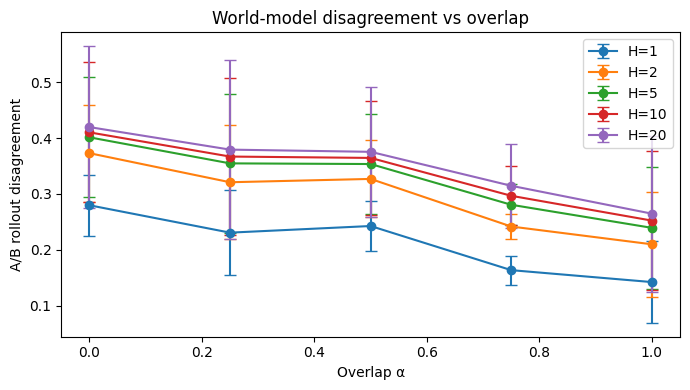

Saved figure: /content/drive/MyDrive/AIAGENT_FINAL/report/figures/fig2_disagreement_vs_horizon.png


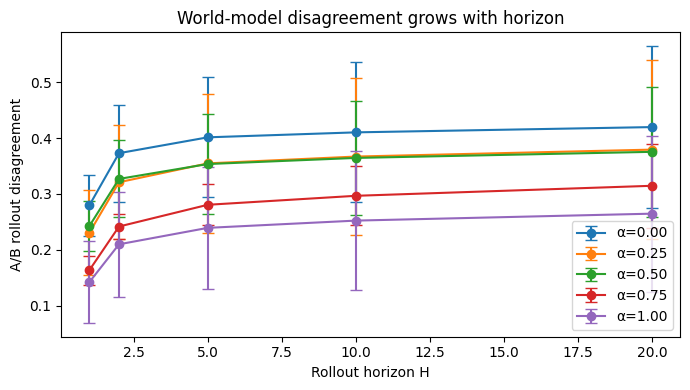

Saved figure: /content/drive/MyDrive/AIAGENT_FINAL/report/figures/fig3_milestone_vs_background_disagreement.png


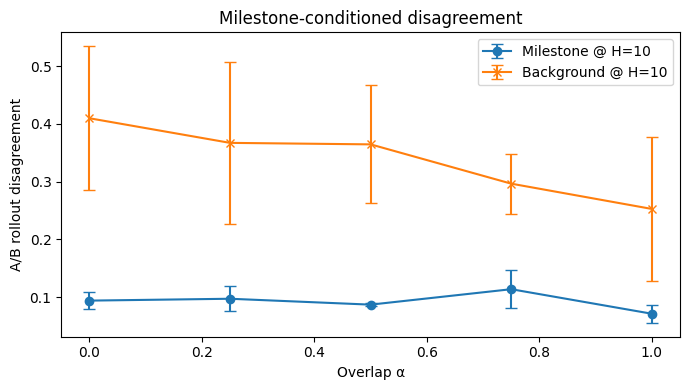

Saved figure: /content/drive/MyDrive/AIAGENT_FINAL/report/figures/fig4_action_agreement_vs_overlap.png


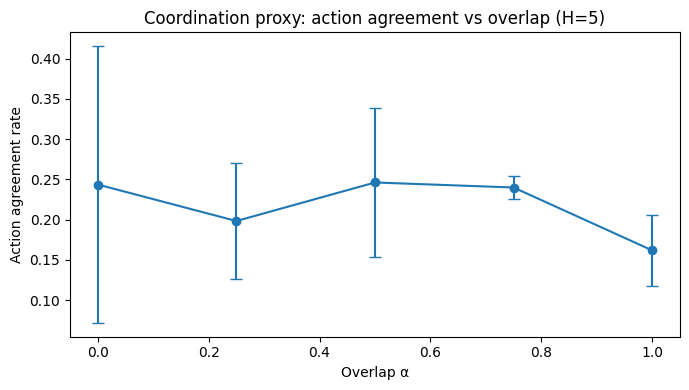

Saved figure: /content/drive/MyDrive/AIAGENT_FINAL/report/figures/fig5_repair_disagreement_vs_calibration.png


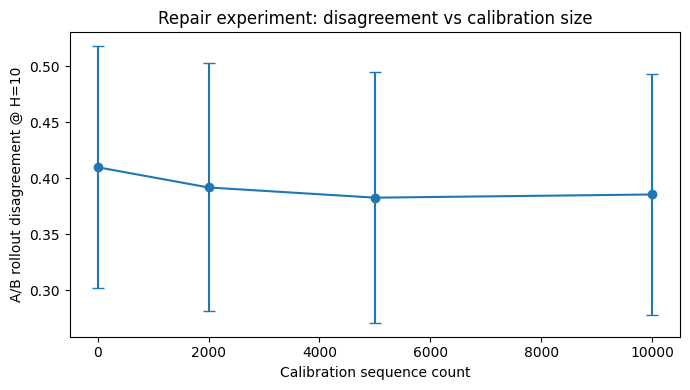

Saved figure: /content/drive/MyDrive/AIAGENT_FINAL/report/figures/fig6_repair_delta_action_agreement.png


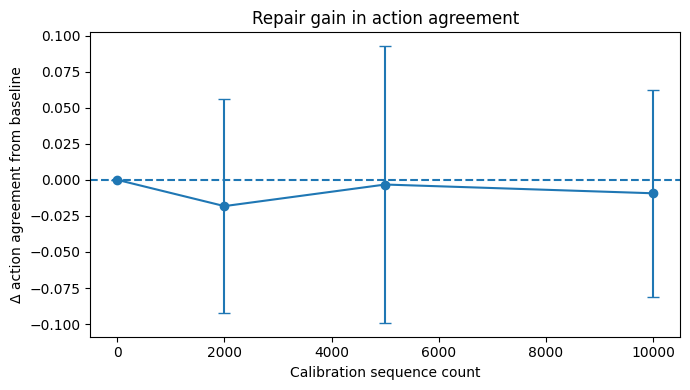

Saved figure: /content/drive/MyDrive/AIAGENT_FINAL/report/figures/diag_disagreement_vs_sequence_ratio.png


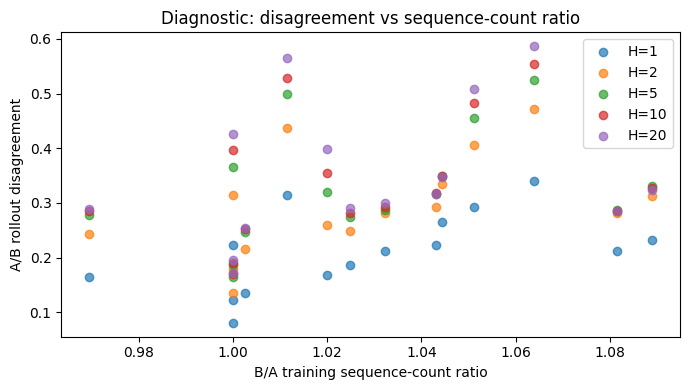

table_overlap


,alpha,H,AB_disagreement_mean,AB_disagreement_sd,AB_disagreement_sem,n
0,0.00,1,0.279789,0.054876,0.031683,3
5,0.25,1,0.230753,0.076451,0.044139,3
10,0.50,1,0.242618,0.044077,0.025448,3
15,0.75,1,0.163590,0.025743,0.014863,3
20,1.00,1,0.142255,0.073076,0.042190,3
1,0.00,2,0.373038,0.086773,0.050098,3
6,0.25,2,0.320995,0.102417,0.059130,3
11,0.50,2,0.326945,0.069031,0.039855,3
16,0.75,2,0.241705,0.022608,0.013053,3
21,1.00,2,0.209885,0.093602,0.054041,3


table_action


,alpha,action_agreement_mean,action_agreement_sd,action_agreement_sem,n
0,0.00,0.243611,0.171850,0.099217,3
1,0.25,0.198283,0.072010,0.041575,3
2,0.50,0.246163,0.092082,0.053163,3
3,0.75,0.239902,0.014348,0.008284,3
4,1.00,0.161760,0.043912,0.025353,3


table_mile


,alpha,milestone_dis_mean,milestone_dis_sd,milestone_dis_sem,n,background_dis_mean,background_dis_sd,background_dis_sem,n_bg
0,0.00,0.093763,0.015135,0.008738,3,0.409932,0.124957,0.072144,3
1,0.25,0.096995,0.021836,0.012607,3,0.367244,0.140548,0.081146,3
2,0.50,0.086780,0.002586,0.001493,3,0.364638,0.102457,0.059154,3
3,0.75,0.113555,0.032602,0.018823,3,0.296507,0.052169,0.030120,3
4,1.00,0.070992,0.015841,0.009146,3,0.252687,0.125201,0.072285,3


table_repair


,calib_seq_count,repair_AB_disagreement_mean,repair_AB_disagreement_sd,repair_AB_disagreement_sem,n,repair_action_agreement_mean,repair_action_agreement_sd,repair_action_agreement_sem,n_act
0,0,0.409756,0.107993,0.035998,9,0.243514,0.148165,0.049388,9
1,2000,0.391708,0.110617,0.036872,9,0.225288,0.096846,0.032282,9
2,5000,0.382620,0.111695,0.037232,9,0.240251,0.096406,0.032135,9
3,10000,0.385460,0.107776,0.035925,9,0.234183,0.089407,0.029802,9


In [ ]:
# Cell 9: Figure 1 — Main result: disagreement vs overlap

plt.figure(figsize=(7, 4))

for H in HORIZONS:
    sub = roll_df[roll_df["H"] == H]
    g = grouped_stats(sub, ["alpha"], "AB_disagreement").sort_values("alpha")
    plt.errorbar(
        g["alpha"].values,
        g["mean"].values,
        yerr=g["sd"].values,
        marker="o",
        capsize=4,
        label=f"H={H}"
    )

plt.xlabel("Overlap α")
plt.ylabel("A/B rollout disagreement")
plt.title("World-model disagreement vs overlap")
plt.legend()
savefig("fig1_disagreement_vs_overlap.png")
plt.show()



# Cell 10: Figure 2 — Disagreement vs horizon, grouped by overlap

plt.figure(figsize=(7, 4))

for alpha in ALPHAS:
    sub = roll_df[roll_df["alpha"] == alpha]
    g = grouped_stats(sub, ["H"], "AB_disagreement").sort_values("H")
    plt.errorbar(
        g["H"].values,
        g["mean"].values,
        yerr=g["sd"].values,
        marker="o",
        capsize=4,
        label=f"α={alpha:.2f}"
    )

plt.xlabel("Rollout horizon H")
plt.ylabel("A/B rollout disagreement")
plt.title("World-model disagreement grows with horizon")
plt.legend()
savefig("fig2_disagreement_vs_horizon.png")
plt.show()



# Cell 11: Figure 3 — Milestone vs background disagreement

if len(mile_df) > 0:
    H_plot = 10
    sub = mile_df[mile_df["H"] == H_plot]

    g_m = grouped_stats(sub, ["alpha"], "milestone_AB_disagreement").sort_values("alpha")
    g_b = grouped_stats(sub, ["alpha"], "background_AB_disagreement").sort_values("alpha")

    plt.figure(figsize=(7, 4))
    plt.errorbar(
        g_m["alpha"].values, g_m["mean"].values, yerr=g_m["sd"].values,
        marker="o", capsize=4, label=f"Milestone @ H={H_plot}"
    )
    plt.errorbar(
        g_b["alpha"].values, g_b["mean"].values, yerr=g_b["sd"].values,
        marker="x", capsize=4, label=f"Background @ H={H_plot}"
    )
    plt.xlabel("Overlap α")
    plt.ylabel("A/B rollout disagreement")
    plt.title("Milestone-conditioned disagreement")
    plt.legend()
    savefig("fig3_milestone_vs_background_disagreement.png")
    plt.show()



# Cell 12: Figure 4 — Coordination proxy: action agreement vs overlap

g = grouped_stats(action_df, ["alpha"], "action_agreement_rate").sort_values("alpha")

plt.figure(figsize=(7, 4))
plt.errorbar(
    g["alpha"].values,
    g["mean"].values,
    yerr=g["sd"].values,
    marker="o",
    capsize=4
)
plt.xlabel("Overlap α")
plt.ylabel("Action agreement rate")
title_suffix = f" (H={PLAN_HORIZON})" if PLAN_HORIZON is not None and PLAN_HORIZON >= 0 else ""
plt.title(f"Coordination proxy: action agreement vs overlap{title_suffix}")
savefig("fig4_action_agreement_vs_overlap.png")
plt.show()



# Cell 13: Figure 5 — Repair: disagreement vs calibration size

plt.figure(figsize=(7, 4))

H_plot = 10
sub = repair_df[repair_df["H"] == H_plot]
g = grouped_stats(sub, ["calib_seq_count"], "AB_disagreement").sort_values("calib_seq_count")

plt.errorbar(
    g["calib_seq_count"].values,
    g["mean"].values,
    yerr=g["sd"].values,
    marker="o",
    capsize=4
)
plt.xlabel("Calibration sequence count")
plt.ylabel("A/B rollout disagreement @ H=10")
plt.title("Repair experiment: disagreement vs calibration size")
savefig("fig5_repair_disagreement_vs_calibration.png")
plt.show()



# Cell 14: Figure 6 — Repair: delta action agreement vs baseline

baseline_map = {}
for (seed, rep), sub in repair_df.groupby(["seed", "replicate_id"]):
    base = sub[(sub["calib_seq_count"] == 0) & (sub["H"] == 10)]
    assert len(base) == 1, f"Missing baseline for seed={seed}, rep={rep}"
    baseline_map[(seed, rep)] = float(base["action_agreement_rate"].iloc[0])

delta_rows = []
for (seed, rep, n_calib), sub in repair_df[repair_df["H"] == 10].groupby(["seed", "replicate_id", "calib_seq_count"]):
    cur = float(sub["action_agreement_rate"].iloc[0])
    delta_rows.append({
        "seed": int(seed),
        "replicate_id": int(rep),
        "calib_seq_count": int(n_calib),
        "delta_action_agreement": cur - baseline_map[(seed, rep)],
    })

delta_df = pd.DataFrame(delta_rows)
g = grouped_stats(delta_df, ["calib_seq_count"], "delta_action_agreement").sort_values("calib_seq_count")

plt.figure(figsize=(7, 4))
plt.errorbar(
    g["calib_seq_count"].values,
    g["mean"].values,
    yerr=g["sd"].values,
    marker="o",
    capsize=4
)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Calibration sequence count")
plt.ylabel("Δ action agreement from baseline")
plt.title("Repair gain in action agreement")
savefig("fig6_repair_delta_action_agreement.png")
plt.show()



# Cell 15: Diagnostic figure — disagreement vs sequence-count ratio

plt.figure(figsize=(7, 4))

for H in HORIZONS:
    sub = roll_df[roll_df["H"] == H]
    plt.scatter(
        sub["sequence_count_ratio"].astype(float).values,
        sub["AB_disagreement"].astype(float).values,
        alpha=0.7,
        label=f"H={H}"
    )

plt.xlabel("B/A training sequence-count ratio")
plt.ylabel("A/B rollout disagreement")
plt.title("Diagnostic: disagreement vs sequence-count ratio")
plt.legend()
savefig("diag_disagreement_vs_sequence_ratio.png")
plt.show()



# Cell 16: Summary tables

# Table A: main overlap-disagreement summary
table_overlap = grouped_stats(roll_df, ["alpha", "H"], "AB_disagreement").sort_values(["H", "alpha"])
table_overlap = table_overlap.rename(columns={
    "mean": "AB_disagreement_mean",
    "sd": "AB_disagreement_sd",
    "sem": "AB_disagreement_sem",
})

# Table B: action agreement summary
table_action = grouped_stats(action_df, ["alpha"], "action_agreement_rate").sort_values("alpha")
table_action = table_action.rename(columns={
    "mean": "action_agreement_mean",
    "sd": "action_agreement_sd",
    "sem": "action_agreement_sem",
})

# Table C: milestone summary at H=10
if len(mile_df) > 0:
    mile_H10 = mile_df[mile_df["H"] == 10].copy()
    table_mile_m = grouped_stats(mile_H10, ["alpha"], "milestone_AB_disagreement").sort_values("alpha")
    table_mile_b = grouped_stats(mile_H10, ["alpha"], "background_AB_disagreement").sort_values("alpha")
    table_mile_m = table_mile_m.rename(columns={"mean": "milestone_dis_mean", "sd": "milestone_dis_sd", "sem": "milestone_dis_sem"})
    table_mile_b = table_mile_b.rename(columns={"mean": "background_dis_mean", "sd": "background_dis_sd", "sem": "background_dis_sem"})
    table_mile = table_mile_m.merge(table_mile_b, on=["alpha"], suffixes=("", "_bg"))
else:
    table_mile = pd.DataFrame()

# Table D: repair summary at H=10
repair_H10 = repair_df[repair_df["H"] == 10].copy()
table_repair_dis = grouped_stats(repair_H10, ["calib_seq_count"], "AB_disagreement").sort_values("calib_seq_count")
table_repair_dis = table_repair_dis.rename(columns={
    "mean": "repair_AB_disagreement_mean",
    "sd": "repair_AB_disagreement_sd",
    "sem": "repair_AB_disagreement_sem",
})

table_repair_act = grouped_stats(repair_H10, ["calib_seq_count"], "action_agreement_rate").sort_values("calib_seq_count")
table_repair_act = table_repair_act.rename(columns={
    "mean": "repair_action_agreement_mean",
    "sd": "repair_action_agreement_sd",
    "sem": "repair_action_agreement_sem",
})

table_repair = table_repair_dis.merge(table_repair_act, on=["calib_seq_count"], suffixes=("", "_act"))

print("table_overlap")
display(table_overlap.head(10))
print("table_action")
display(table_action)
if len(table_mile) > 0:
    print("table_mile")
    display(table_mile)
print("table_repair")
display(table_repair)

In [ ]:
# Cell 17: Save summary tables

table_overlap.to_csv(os.path.join(TABLE_DIR, "table_overlap_disagreement.csv"), index=False)
table_action.to_csv(os.path.join(TABLE_DIR, "table_action_agreement.csv"), index=False)
if len(table_mile) > 0:
    table_mile.to_csv(os.path.join(TABLE_DIR, "table_milestone_conditioned.csv"), index=False)
table_repair.to_csv(os.path.join(TABLE_DIR, "table_repair_summary.csv"), index=False)

summary_tables_csv = os.path.join(TABLE_DIR, "summary_tables.csv")
all_tables = []

tmp = table_overlap.copy()
tmp["table_name"] = "overlap_disagreement"
all_tables.append(tmp)

tmp = table_action.copy()
tmp["table_name"] = "action_agreement"
all_tables.append(tmp)

if len(table_mile) > 0:
    tmp = table_mile.copy()
    tmp["table_name"] = "milestone_conditioned"
    all_tables.append(tmp)

tmp = table_repair.copy()
tmp["table_name"] = "repair_summary"
all_tables.append(tmp)

pd.concat(all_tables, axis=0, ignore_index=True).to_csv(summary_tables_csv, index=False)
print("Saved CSV tables to:", TABLE_DIR)

Saved CSV tables to: /content/drive/MyDrive/AIAGENT_FINAL/report/tables


In [ ]:
# Cell 18: Build summary_metrics.json

summary_metrics = {
    "project": "World-Model Alignment as a Prerequisite for Multi-Agent Coordination",
    "generated_from": {
        "rollout_results": ROLL_RESULTS_PATH,
        "action_results": ACTION_RESULTS_PATH,
        "repair_results": REPAIR_RESULTS_PATH,
    },
    "core_findings": {},
    "tables": {
        "table_overlap_disagreement_csv": os.path.join(TABLE_DIR, "table_overlap_disagreement.csv"),
        "table_action_agreement_csv": os.path.join(TABLE_DIR, "table_action_agreement.csv"),
        "table_repair_summary_csv": os.path.join(TABLE_DIR, "table_repair_summary.csv"),
        "summary_tables_csv": summary_tables_csv,
    },
    "figures": sorted(glob.glob(os.path.join(FIG_DIR, "*.png"))),
}

# Main overlap effect: alpha=0 vs alpha=1 by horizon
alpha0 = roll_df[roll_df["alpha"] == 0.0]
alpha1 = roll_df[roll_df["alpha"] == 1.0]

overlap_effect = {}
for H in HORIZONS:
    d0 = alpha0[alpha0["H"] == H]["AB_disagreement"].astype(float).values
    d1 = alpha1[alpha1["H"] == H]["AB_disagreement"].astype(float).values
    overlap_effect[str(H)] = {
        "alpha0_mean": float(np.mean(d0)),
        "alpha1_mean": float(np.mean(d1)),
        "absolute_drop": float(np.mean(d0) - np.mean(d1)),
        "relative_drop_pct": float(100.0 * (np.mean(d0) - np.mean(d1)) / np.mean(d0)),
    }

summary_metrics["core_findings"]["disagreement_overlap_effect"] = overlap_effect

# Horizon growth at alpha=0 and alpha=1
horizon_growth = {}
for alpha in [0.0, 1.0]:
    sub = roll_df[roll_df["alpha"] == alpha]
    g = grouped_stats(sub, ["H"], "AB_disagreement").sort_values("H")
    horizon_growth[str(alpha)] = {
        "H_values": [int(x) for x in g["H"].tolist()],
        "means": [float(x) for x in g["mean"].tolist()],
    }
summary_metrics["core_findings"]["horizon_growth"] = horizon_growth

# Milestone vs background at H=10
if len(mile_df) > 0:
    sub = mile_df[mile_df["H"] == 10]
    mile_summary = {}
    for alpha in ALPHAS:
        ss = sub[sub["alpha"] == alpha]
        mile_summary[str(alpha)] = {
            "milestone_mean": float(np.mean(ss["milestone_AB_disagreement"].astype(float).values)),
            "background_mean": float(np.mean(ss["background_AB_disagreement"].astype(float).values)),
        }
    summary_metrics["core_findings"]["milestone_conditioned_H10"] = mile_summary

# Action agreement summary
action_summary = {}
for alpha in ALPHAS:
    ss = action_df[action_df["alpha"] == alpha]["action_agreement_rate"].astype(float).values
    action_summary[str(alpha)] = {
        "mean": float(np.mean(ss)),
        "sd": float(np.std(ss, ddof=1)) if len(ss) > 1 else 0.0,
    }
summary_metrics["core_findings"]["action_agreement"] = action_summary

# Repair summary at H=10
repair_summary = {}
sub = repair_df[repair_df["H"] == 10]
for n_calib in CALIB_SEQ_COUNTS:
    ss = sub[sub["calib_seq_count"] == n_calib]
    repair_summary[str(n_calib)] = {
        "AB_disagreement_mean": float(np.mean(ss["AB_disagreement"].astype(float).values)),
        "action_agreement_mean": float(np.mean(ss["action_agreement_rate"].astype(float).values)),
    }
summary_metrics["core_findings"]["repair_summary_H10"] = repair_summary

summary_json_path = os.path.join(TABLE_DIR, "summary_metrics.json")
with open(summary_json_path, "w") as f:
    json.dump(summary_metrics, f, indent=2)

print("Saved:", summary_json_path)

Saved: /content/drive/MyDrive/AIAGENT_FINAL/report/tables/summary_metrics.json


In [ ]:
# Cell 19: Print report-ready takeaway block

print("\nREPORT-READY TAKEAWAYS\n")

for H in HORIZONS:
    eff = summary_metrics["core_findings"]["disagreement_overlap_effect"][str(H)]
    print(
        f"H={H}: disagreement drops from {eff['alpha0_mean']:.3f} at α=0.00 "
        f"to {eff['alpha1_mean']:.3f} at α=1.00 "
        f"({eff['relative_drop_pct']:.1f}% reduction)."
    )

if len(mile_df) > 0:
    print("\nAt H=10, background disagreement is consistently larger than milestone disagreement.")
    for alpha in ALPHAS:
        ms = summary_metrics["core_findings"]["milestone_conditioned_H10"][str(alpha)]
        print(
            f"α={alpha:.2f}: milestone={ms['milestone_mean']:.3f}, "
            f"background={ms['background_mean']:.3f}"
        )

print("\nAction agreement remains exploratory/noisy relative to rollout disagreement.")
for alpha in ALPHAS:
    aa = summary_metrics["core_findings"]["action_agreement"][str(alpha)]
    print(f"α={alpha:.2f}: action_agreement={aa['mean']:.3f} ± {aa['sd']:.3f}")

print("\nRepair experiment shows partial predictive-alignment recovery.")
for n_calib in CALIB_SEQ_COUNTS:
    rs = summary_metrics["core_findings"]["repair_summary_H10"][str(n_calib)]
    print(
        f"n={n_calib}: H10_disagreement={rs['AB_disagreement_mean']:.3f}, "
        f"action_agreement={rs['action_agreement_mean']:.3f}"
    )



REPORT-READY TAKEAWAYS

H=1: disagreement drops from 0.280 at α=0.00 to 0.142 at α=1.00 (49.2% reduction).
H=2: disagreement drops from 0.373 at α=0.00 to 0.210 at α=1.00 (43.7% reduction).
H=5: disagreement drops from 0.401 at α=0.00 to 0.239 at α=1.00 (40.4% reduction).
H=10: disagreement drops from 0.410 at α=0.00 to 0.252 at α=1.00 (38.5% reduction).
H=20: disagreement drops from 0.420 at α=0.00 to 0.265 at α=1.00 (36.9% reduction).

At H=10, background disagreement is consistently larger than milestone disagreement.
α=0.00: milestone=0.094, background=0.410
α=0.25: milestone=0.097, background=0.367
α=0.50: milestone=0.087, background=0.365
α=0.75: milestone=0.114, background=0.297
α=1.00: milestone=0.071, background=0.253

Action agreement remains exploratory/noisy relative to rollout disagreement.
α=0.00: action_agreement=0.244 ± 0.172
α=0.25: action_agreement=0.198 ± 0.072
α=0.50: action_agreement=0.246 ± 0.092
α=0.75: action_agreement=0.240 ± 0.014
α=1.00: action_agreement=0.1

In [ ]:
# Cell 20: Final inventory check

expected_figs = [
    "fig1_disagreement_vs_overlap.png",
    "fig2_disagreement_vs_horizon.png",
    "fig4_action_agreement_vs_overlap.png",
    "fig5_repair_disagreement_vs_calibration.png",
    "fig6_repair_delta_action_agreement.png",
]
for fn in expected_figs:
    path = os.path.join(FIG_DIR, fn)
    assert os.path.exists(path), f"Missing expected figure: {path}"

assert os.path.exists(os.path.join(TABLE_DIR, "summary_metrics.json"))
assert os.path.exists(os.path.join(TABLE_DIR, "table_overlap_disagreement.csv"))
assert os.path.exists(os.path.join(TABLE_DIR, "table_action_agreement.csv"))
assert os.path.exists(os.path.join(TABLE_DIR, "table_repair_summary.csv"))

print("Notebook 9 completed cleanly.")

Notebook 9 completed cleanly.
